# BrushCue Example: Shredder

<a href="https://colab.research.google.com/github/ditotechnologies/monorepo/blob/main/py/brushcue/examples/shredder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/shredder

In [ ]:
!pip install brushcue

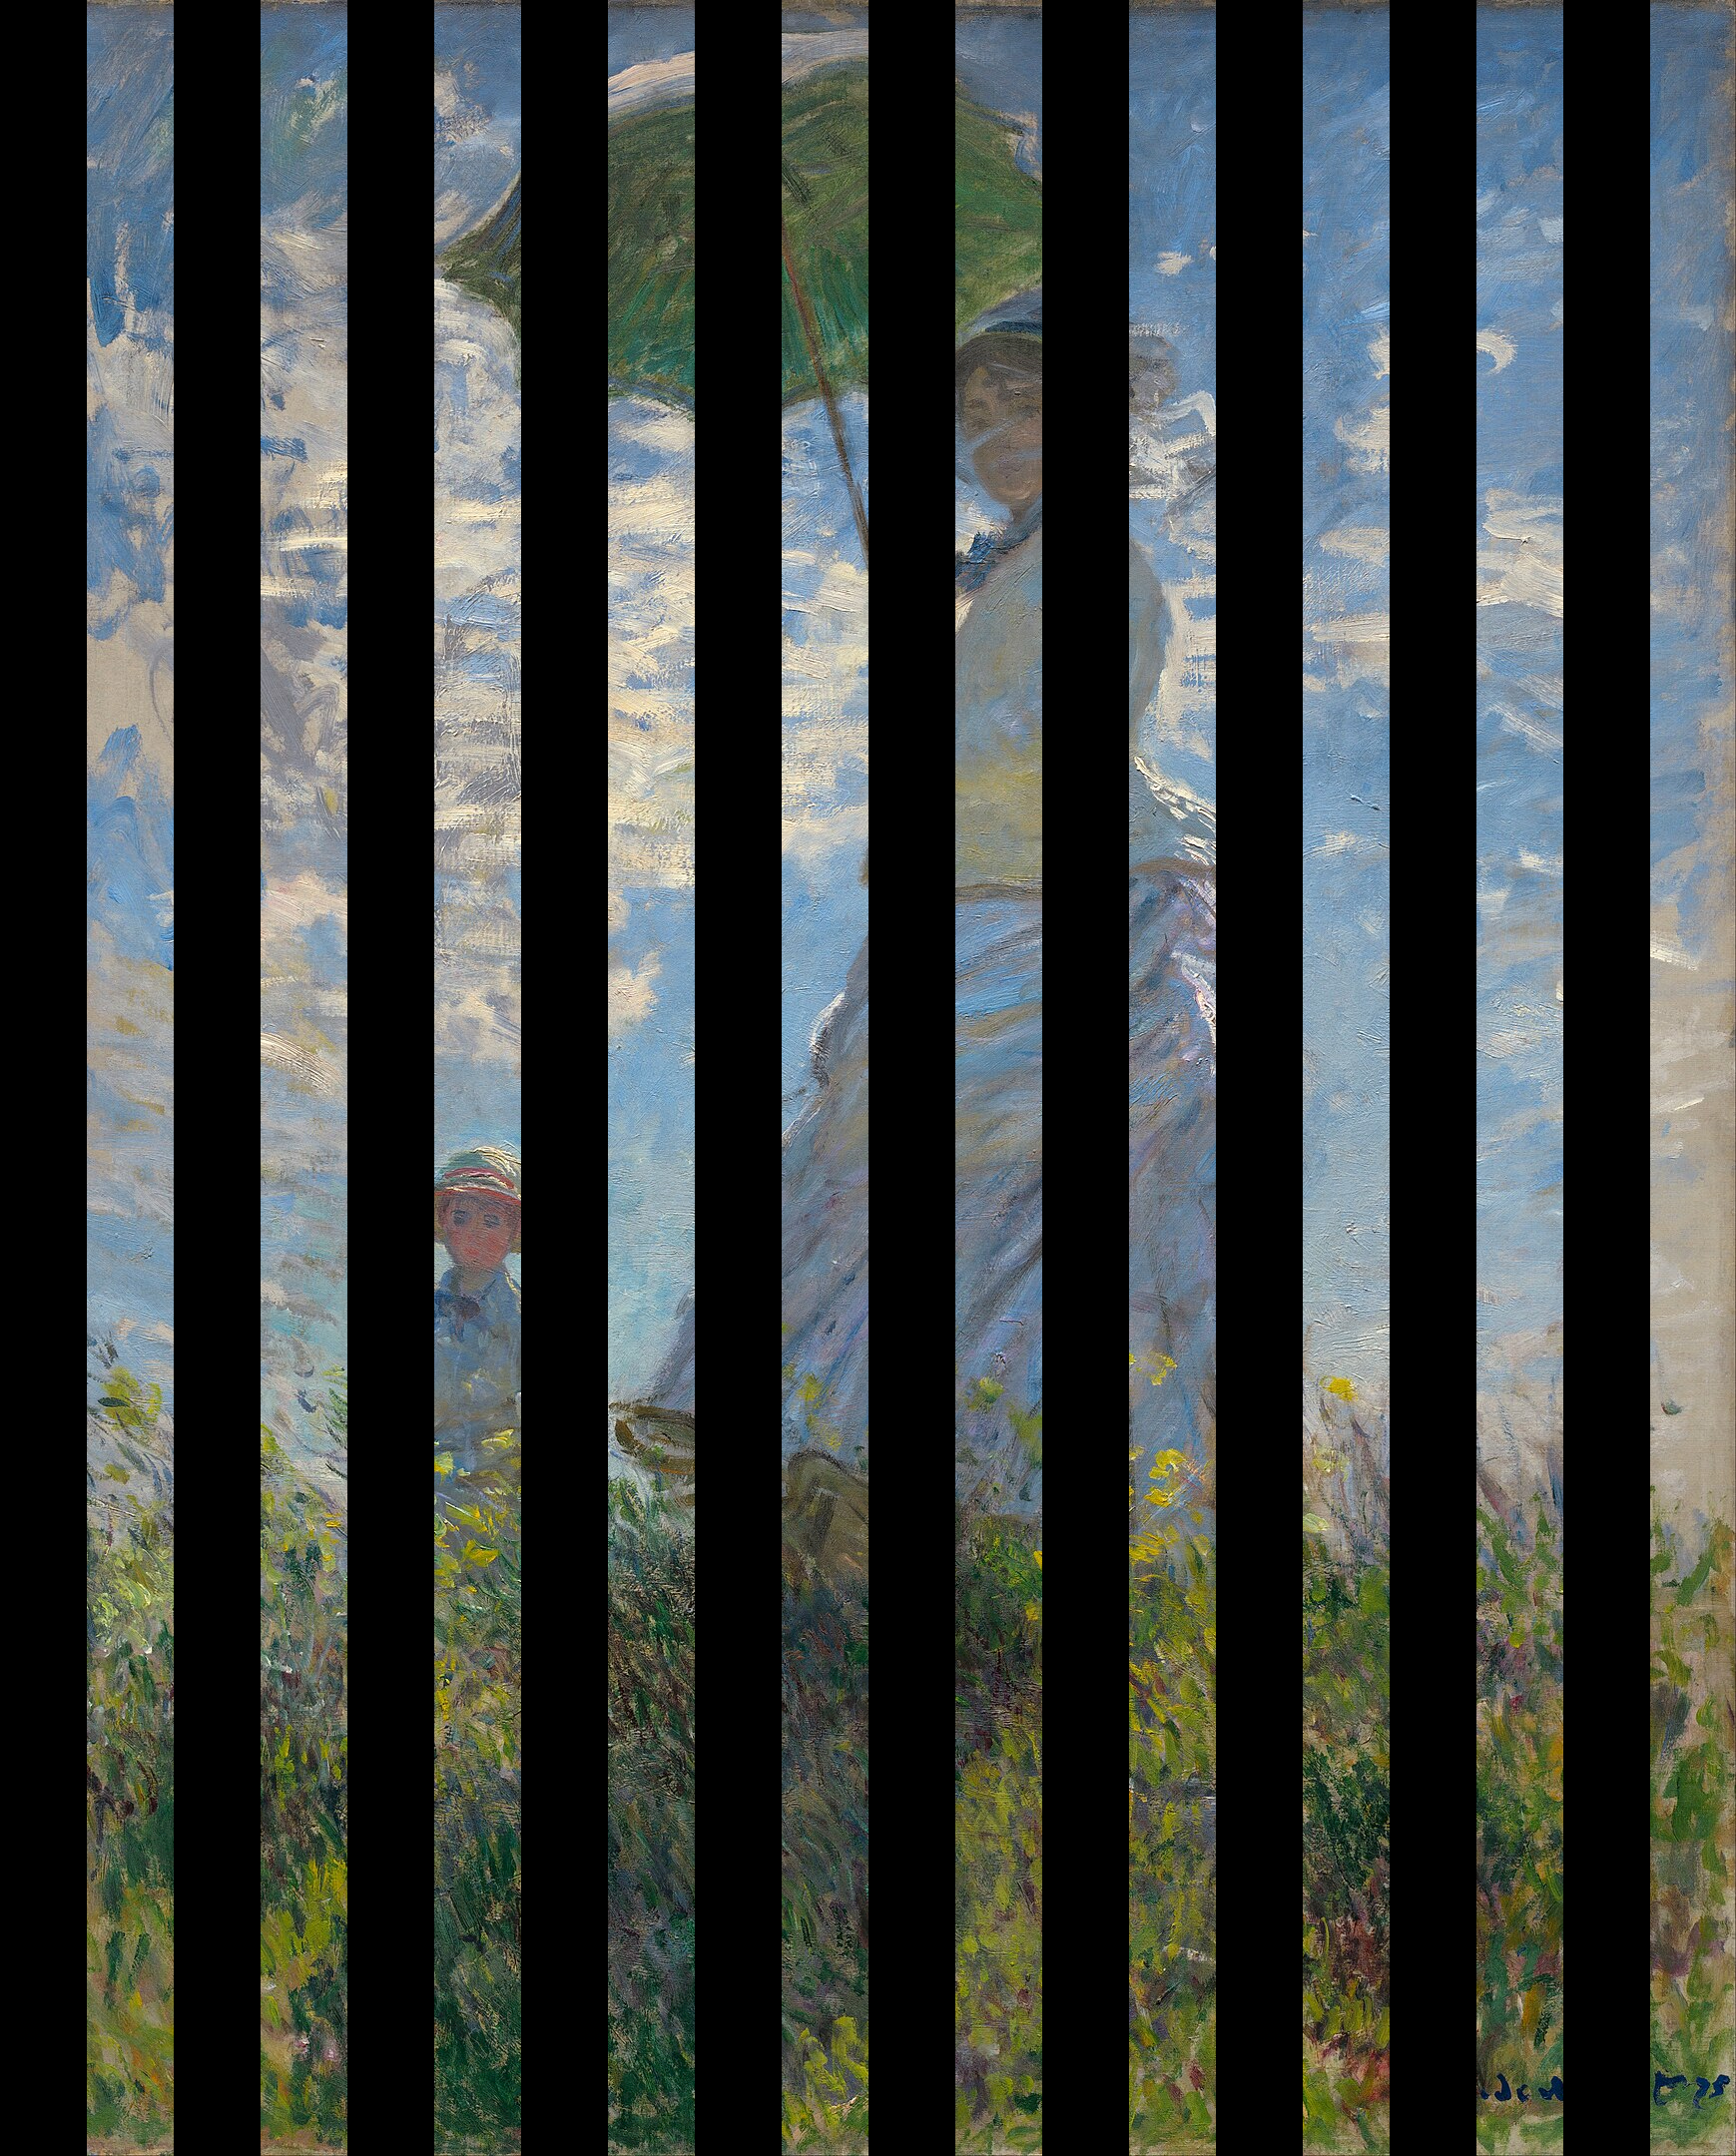

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("  let dimensions = textureDimensions(input_texture);\n  let current_strip = f32(dimensions.x) / f32(number_of_strips);\n  let strip_index = u32(floor(f32(position.x) / current_strip));\n  \n  // Set alternating strips to transparent\n  if (strip_index % 2u == 0u) {\n      return background_color;\n  }\n  \n  return input;")
string_constant_3 = brushcue.string_constant("// You can write your helper functions here if you need them.")
composition_color_profile_4 = brushcue.composition_color_profile(input_image_1)
bool_constant_5 = brushcue.bool_constant(True)
string_constant_6 = brushcue.string_constant("background_color")
dictionary_create_7 = brushcue.dictionary_create()
string_constant_8 = brushcue.string_constant("number_of_strips")
rgba_color_constant_9 = brushcue.r_g_b_a_color_constant(0, 0, 0, 1)
int_constant_10 = brushcue.int_constant(20)
background_color_11 = brushcue.r_g_b_a_color_passthrough(rgba_color_constant_9)
number_of_strips_12 = brushcue.int_passthrough(int_constant_10)
int_add_to_dictionary_13 = brushcue.int_add_to_dictionary(dictionary_create_7, string_constant_8, number_of_strips_12)
rgba_color_add_to_dictionary_14 = brushcue.r_g_b_a_color_add_to_dictionary(int_add_to_dictionary_13, string_constant_6, background_color_11)
shredder_shader_15 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, composition_color_profile_4, composition_color_profile_4, rgba_color_add_to_dictionary_14, bool_constant_5)
result_image_16 = brushcue.composition_passthrough(shredder_shader_15)

ctx = brushcue.Context()
result = result_image_16.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img
